# Richards (6th ed.) Chapter 1 Problems 1.1 to 1.3

In [1]:
# Cell 1
# I will now import the libraries I need for all three problems.
# ---
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.titlelocation": "center", "font.size": 11})

## Problem 1.1  Spectral space for 0.65 µm and 1.0 µm

In [2]:
# Cell 2
# I will now set typical reflectance values (%) for water, vegetation and soil.
# These are read approximately off the standard spectral reflectance curves.
# ---
classes = {
    #              0.65 um  1.0 um
    "Water":      (5.0,     2.0),
    "Vegetation": (6.0,    45.0),
    "Soil":       (25.0,   32.0),
}
colors = {"Water": "tab:blue", "Vegetation": "tab:green", "Soil": "tab:brown"}

# I also add some scatter around each mean so it looks like real pixel clusters
rng = np.random.default_rng(1)
clusters = {k: rng.normal(v, [1.5, 3.0], size=(150, 2)) for k, v in classes.items()}

In [3]:
# Cell 3
# I will now write the decision lines and a simple rule to label any pixel.
#   Line A: x + y = 15   -> below this, the pixel is water
#   Line B: y = 3x       -> above this (and above line A), vegetation, otherwise soil
# ---
def classify_1(x, y):
    if x + y < 15:
        return "Water"
    elif y > 3 * x:
        return "Vegetation"
    else:
        return "Soil"

# quick check on the class means
for name, (x, y) in classes.items():
    print(f"{name:11s} ({x:4.1f}, {y:4.1f}) -> {classify_1(x, y)}")

Water       ( 5.0,  2.0) -> Water
Vegetation  ( 6.0, 45.0) -> Vegetation
Soil        (25.0, 32.0) -> Soil


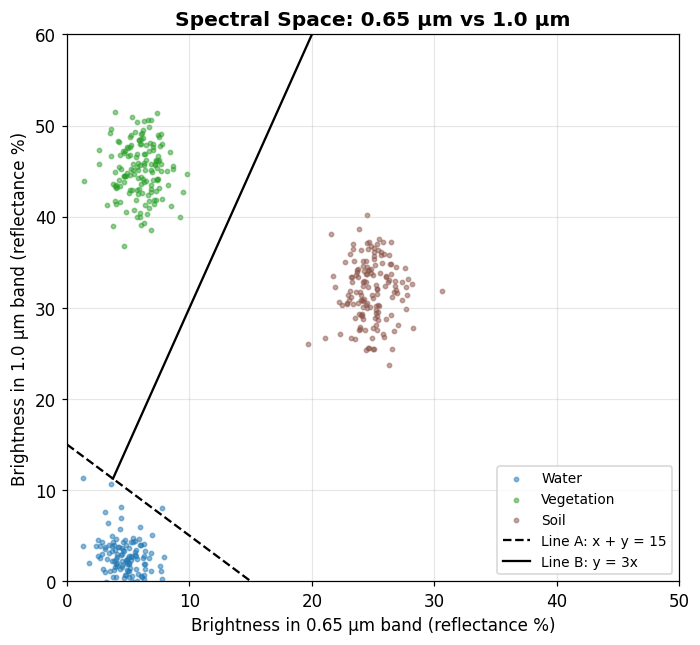

In [4]:
# Cell 4
# I will now plot the spectral space with the clusters and the two lines.
# ---
fig, ax = plt.subplots(figsize=(6.5, 6))
for k, pts in clusters.items():
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5, color=colors[k], label=k)

x = np.linspace(0, 60, 200)
ax.plot(x, 15 - x, "k--", lw=1.5, label="Line A: x + y = 15")
x_b = np.linspace(15/4, 20, 100)        # line B starts where it meets line A
ax.plot(x_b, 3 * x_b, "k-", lw=1.5, label="Line B: y = 3x")

ax.set_xlim(0, 50); ax.set_ylim(0, 60)
ax.set_xlabel("Brightness in 0.65 µm band (reflectance %)")
ax.set_ylabel("Brightness in 1.0 µm band (reflectance %)")
ax.set_title("Spectral Space: 0.65 µm vs 1.0 µm")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Problem 1.1 (repeat)  Spectral space for 0.95 µm and 1.05 µm

In [5]:
# Cell 5
# I will now repeat it for 0.95 um and 1.05 um. Both are on the NIR plateau,
# so every class sits close to the 1:1 line.
# ---
classes2 = {
    #              0.95 um  1.05 um
    "Water":      (1.0,     0.5),
    "Vegetation": (47.0,   48.0),
    "Soil":       (33.0,   35.0),
}
clusters2 = {k: rng.normal(v, [2.5, 2.5], size=(150, 2)) for k, v in classes2.items()}

# Both lines are now perpendicular to the 1:1 line, so only brightness separates classes
def classify_2(x, y):
    if x + y < 35:
        return "Water"
    elif x + y < 80:
        return "Soil"
    else:
        return "Vegetation"

for name, (x, y) in classes2.items():
    print(f"{name:11s} ({x:4.1f}, {y:4.1f}) -> {classify_2(x, y)}")

Water       ( 1.0,  0.5) -> Water
Vegetation  (47.0, 48.0) -> Vegetation
Soil        (33.0, 35.0) -> Soil


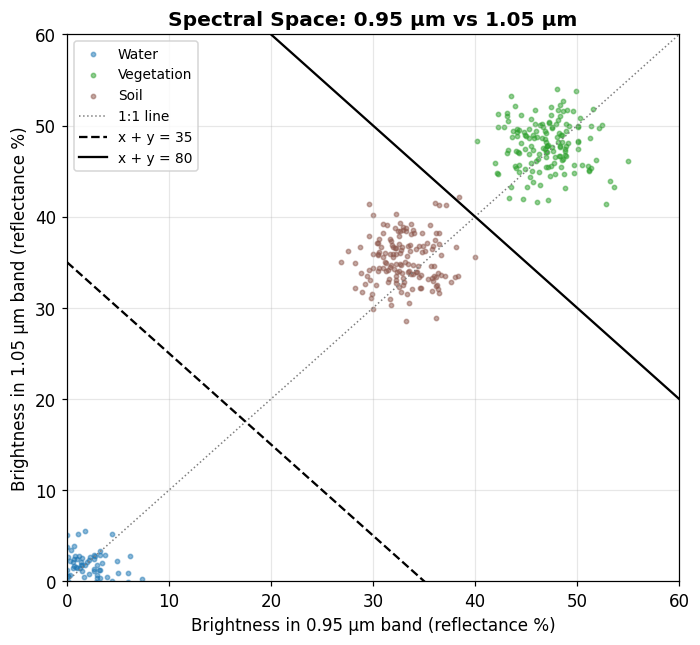

Band correlation, 0.65 vs 1.0 um  : 0.261
Band correlation, 0.95 vs 1.05 um : 0.982


In [6]:
# Cell 6
# I will now plot the second spectral space.
# ---
fig, ax = plt.subplots(figsize=(6.5, 6))
for k, pts in clusters2.items():
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5, color=colors[k], label=k)

x = np.linspace(0, 60, 200)
ax.plot(x, x, color="gray", lw=1, ls=":", label="1:1 line")
ax.plot(x, 35 - x, "k--", lw=1.5, label="x + y = 35")
ax.plot(x, 80 - x, "k-", lw=1.5, label="x + y = 80")

ax.set_xlim(0, 60); ax.set_ylim(0, 60)
ax.set_xlabel("Brightness in 0.95 µm band (reflectance %)")
ax.set_ylabel("Brightness in 1.05 µm band (reflectance %)")
ax.set_title("Spectral Space: 0.95 µm vs 1.05 µm")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# correlation between the two bands (all pixels together) for comparison
all1 = np.vstack(list(clusters.values()))
all2 = np.vstack(list(clusters2.values()))
print("Band correlation, 0.65 vs 1.0 um  :", round(np.corrcoef(all1.T)[0, 1], 3))
print("Band correlation, 0.95 vs 1.05 um :", round(np.corrcoef(all2.T)[0, 1], 3))

## Problem 1.2  Data volume of one frame

In [7]:
# Cell 7
# I will now enter the sensor specs: swath (km), band groups as
# (pixel size in m, number of bands), and bits per pixel.
# ---
sensors = {
    "NOAA AVHRR":   {"swath_km": 2940, "groups": [(1100, 5)],                 "bits": 10},
    "Aqua MODIS":   {"swath_km": 2330, "groups": [(250, 2), (500, 5), (1000, 29)], "bits": 12},
    "Landsat ETM+": {"swath_km": 185,  "groups": [(15, 1), (30, 6), (60, 1)],  "bits": 8},
    "SPOT HRG MS":  {"swath_km": 60,   "groups": [(10, 3), (20, 1)],          "bits": 8},
    "GeoEye MS":    {"swath_km": 15.2, "groups": [(1.65, 4)],                 "bits": 11},
}
# pixel size I use on the x axis (the one most bands have)
rep_pixel = {"NOAA AVHRR": 1100, "Aqua MODIS": 1000, "Landsat ETM+": 30,
             "SPOT HRG MS": 10, "GeoEye MS": 1.65}

In [8]:
# Cell 8
# I will now compute the frame volume. Frame = swath x swath, so
#   pixels per band = (swath / pixel)^2
#   bits = pixels x bands x bits per pixel
# ---
results = {}
print(f"{'Sensor':14s}{'Bands':>6s}{'Total (MB)':>12s}{'Avg/band (MB)':>15s}")
for name, s in sensors.items():
    S = s["swath_km"] * 1000
    total_bits, nbands = 0, 0
    for pix, nb in s["groups"]:
        n_pix = (S / pix) ** 2
        total_bits += n_pix * nb * s["bits"]
        nbands += nb
    total_MB = total_bits / 8 / 1e6
    avg_MB = total_MB / nbands
    results[name] = (total_MB, avg_MB)
    print(f"{name:14s}{nbands:6d}{total_MB:12.1f}{avg_MB:15.1f}")

Sensor         Bands  Total (MB)  Avg/band (MB)
NOAA AVHRR         5        44.6            8.9
Aqua MODIS        36       659.6           18.3
Landsat ETM+       8       389.8           48.7
SPOT HRG MS        4       117.0           29.2
GeoEye MS          4       466.7          116.7


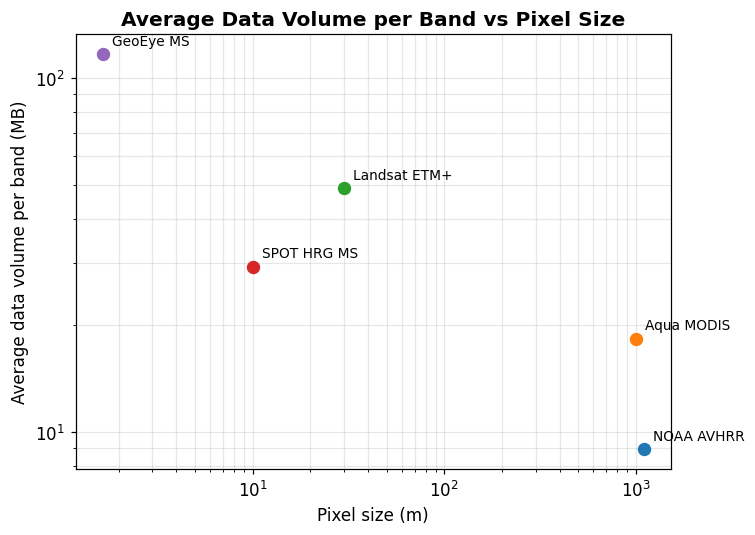

In [9]:
# Cell 9
# I will now plot average data volume per band against pixel size (log-log).
# ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, (tot, avg) in results.items():
    p = rep_pixel[name]
    ax.scatter(p, avg, s=60, zorder=3)
    ax.annotate(name, (p, avg), textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Pixel size (m)")
ax.set_ylabel("Average data volume per band (MB)")
ax.set_title("Average Data Volume per Band vs Pixel Size")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Problem 1.3  Swath width vs repeat cycle at 800 km

In [10]:
# Cell 10
# I will now get the orbital period from Kepler's third law.
# ---
mu = 3.986e14          # Earth's GM (m^3/s^2)
Re = 6378e3            # equatorial radius (m)
h = 800e3              # altitude (m)

T = 2 * np.pi * np.sqrt((Re + h) ** 3 / mu)
orbits_per_day = 86400 / T
equator_km = 2 * np.pi * Re / 1000
shift_km = equator_km / orbits_per_day      # westward shift of track per orbit

print(f"Period          : {T:.0f} s = {T/60:.1f} min")
print(f"Orbits per day  : {orbits_per_day:.2f}")
print(f"Track shift/orbit at equator: {shift_km:.0f} km")

Period          : 6052 s = 100.9 min
Orbits per day  : 14.28
Track shift/orbit at equator: 2807 km


In [11]:
# Cell 11
# I will now apply the coverage condition with 10% overlap:
#   (orbits in N days) x 0.9 x swath = equator length
#   => swath = equator / (0.9 x orbits_per_day x N)
# ---
overlap = 0.10
K = equator_km / ((1 - overlap) * orbits_per_day)   # km x day
print(f"swath (km) x repeat cycle (days) = {K:.0f}")

for N in [1, 2, 4, 8, 16, 26]:
    print(f"N = {N:2d} days -> swath = {K/N:7.1f} km")

swath (km) x repeat cycle (days) = 3119
N =  1 days -> swath =  3119.1 km
N =  2 days -> swath =  1559.5 km
N =  4 days -> swath =   779.8 km
N =  8 days -> swath =   389.9 km
N = 16 days -> swath =   194.9 km
N = 26 days -> swath =   120.0 km


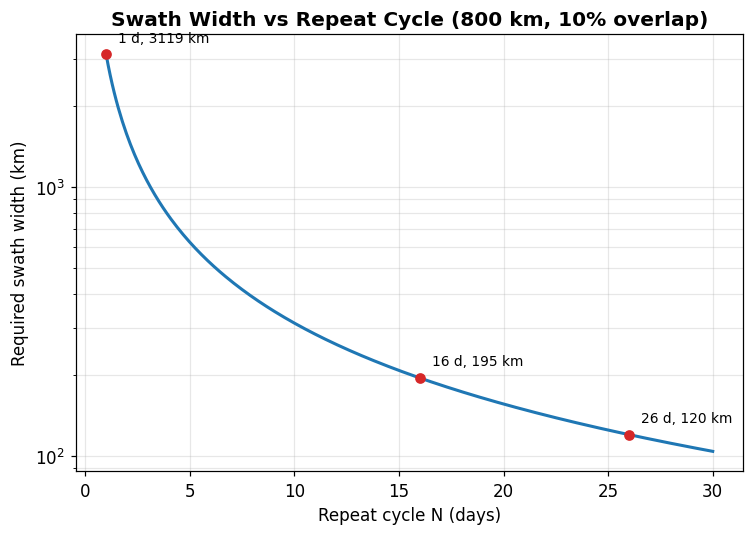

In [12]:
# Cell 12
# I will now plot the relationship.
# ---
N = np.linspace(1, 30, 300)
w = K / N

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(N, w, lw=2)
for n in [1, 16, 26]:
    ax.plot(n, K / n, "o", color="tab:red")
    ax.annotate(f"{n} d, {K/n:.0f} km", (n, K / n), textcoords="offset points",
                xytext=(8, 8), fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("Repeat cycle N (days)")
ax.set_ylabel("Required swath width (km)")
ax.set_title("Swath Width vs Repeat Cycle (800 km, 10% overlap)")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()